In [48]:
# Netflix data analysis

# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [49]:
# Load Dataset

df = pd.read_csv("../data/netflix_titles.csv")

In [50]:
# Understand the dataset

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [51]:
df.shape

(8807, 12)

In [52]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [54]:
# Data Cleaning

In [55]:
# finding null values in the dataset

df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [56]:
# finding duplicate values in the dataset

df.duplicated().sum()

np.int64(0)

In [57]:
# filling null values of director column with 'Unknown'

df['director'] = df['director'].fillna('Unknown')

In [58]:
# verifiy derictor column

df['director'].isnull().sum()

np.int64(0)

In [59]:
# filling null values of cast column with 'Unknown'

df['cast'] = df['cast'].fillna('unknown')

In [60]:
# Remove null valued row of columns : country, date_added, rating
# and verify

df = df.dropna(subset=['country', 'date_added', 'rating'])
df.isnull().sum()


show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
dtype: int64

In [61]:
# Change datatype of 'date_added' column to datetime

df['date_added'] = pd.to_datetime(df['date_added'], format = "mixed")
df['date_added']

0      2021-09-25
1      2021-09-24
4      2021-09-24
7      2021-09-24
8      2021-09-24
          ...    
8801   2016-03-09
8802   2019-11-20
8804   2019-11-01
8805   2020-01-11
8806   2019-03-02
Name: date_added, Length: 7964, dtype: datetime64[us]

In [62]:
# validate
df.info()

<class 'pandas.DataFrame'>
Index: 7964 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       7964 non-null   str           
 1   type          7964 non-null   str           
 2   title         7964 non-null   str           
 3   director      7964 non-null   str           
 4   cast          7964 non-null   str           
 5   country       7964 non-null   str           
 6   date_added    7964 non-null   datetime64[us]
 7   release_year  7964 non-null   int64         
 8   rating        7964 non-null   str           
 9   duration      7961 non-null   str           
 10  listed_in     7964 non-null   str           
 11  description   7964 non-null   str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 808.8 KB


In [63]:
# Exploratory Data Analysis (EDA)

In [64]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...


In [65]:
# Find uniques values of 'type' column and their counts

df['type'].value_counts()

type
Movie      5690
TV Show    2274
Name: count, dtype: int64

Netflix has more movies(6126) than TV shows(2664) , shows up that movies make up the majority of its catolog.

In [66]:
# Find director with most movies and shows descending order

Top_Directors = df[df['director'] != 'Unknown']['director'].value_counts().head(10)
Top_Directors

director
Raúl Campos, Jan Suter    18
Marcus Raboy              15
Jay Karas                 14
Cathy Garcia-Molina       13
Youssef Chahine           12
Martin Scorsese           12
Jay Chapman               12
Steven Spielberg          11
Don Michael Paul          10
David Dhawan               9
Name: count, dtype: int64

Most work director with netflix has 19 Tv Shows/ Movies on Netflix

In [67]:
# Find top 10 actors with most movies and shows.
actors = df['cast'].str.split(',').explode().str.strip()

most_frequent_actors = actors[actors != 'unknown'].value_counts().head(10)
most_frequent_actors

cast
Anupam Kher         43
Shah Rukh Khan      34
Naseeruddin Shah    31
Akshay Kumar        30
Om Puri             30
Takahiro Sakurai    29
Amitabh Bachchan    28
Yuki Kaji           28
Paresh Rawal        28
Boman Irani         27
Name: count, dtype: int64

This Shows that most worked actor is Anupam Kher

In [68]:
# Top countries with most movies and shows

df['country'].value_counts().head(10)

country
United States     2812
India              972
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

Most of the movies are from United states (2812)

In [69]:
# Top Genres

genres = df['listed_in'].str.split(',').explode().str.strip()
genres.value_counts().head(10)

listed_in
International Movies      2543
Dramas                    2316
Comedies                  1580
International TV Shows    1126
Action & Adventure         817
Documentaries              794
Independent Movies         745
TV Dramas                  662
Romantic Movies            588
Thrillers                  549
Name: count, dtype: int64

It shows that International Movies(2543), Dramas (2316), Comedies(1580) and Internation TV Shows(1126) are the most famous genres on netflix.

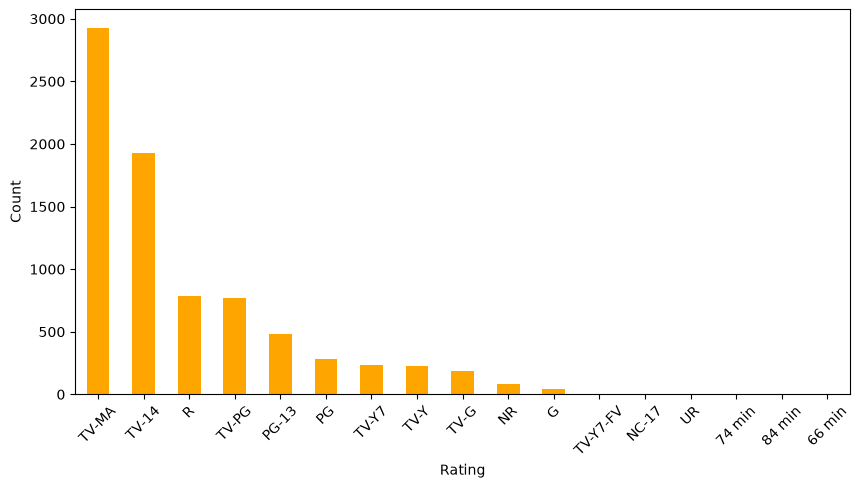

In [70]:
# top rated movies and shows

ratings = df['rating'].value_counts()

ratings.plot(
    kind='bar', 
    figsize=(10, 5), 
    color='orange'
)

plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [71]:
df["rating"].value_counts(normalize=True) * 100

rating
TV-MA       36.778001
TV-14       24.196384
R            9.894525
TV-PG        9.681065
PG-13        6.052235
PG           3.528378
TV-Y7        2.950779
TV-Y         2.850326
TV-G         2.385736
NR           0.991964
G            0.514817
TV-Y7-FV     0.062783
NC-17        0.037670
UR           0.037670
74 min       0.012557
84 min       0.012557
66 min       0.012557
Name: proportion, dtype: float64

Chart shows that most common rating is TV -MA that is Indicating that the large portion of the content is intended for mature audience.

In [72]:
# content release by year.

highest_release_year = df['release_year'].value_counts().head(10)
highest_release_year

release_year
2018    1037
2017     966
2019     913
2020     852
2016     837
2015     512
2021     383
2014     333
2013     268
2012     221
Name: count, dtype: int64

This shows most of the Tvshows/Movies are show from 2018 release.

In [73]:
# content added to netflix by year

date_added = df['date_added'].dt.year.value_counts()
date_added

date_added
2019    1858
2020    1771
2018    1529
2021    1140
2017    1122
2016     409
2015      79
2014      24
2011      13
2013      11
2012       3
2009       2
2008       2
2010       1
Name: count, dtype: int64

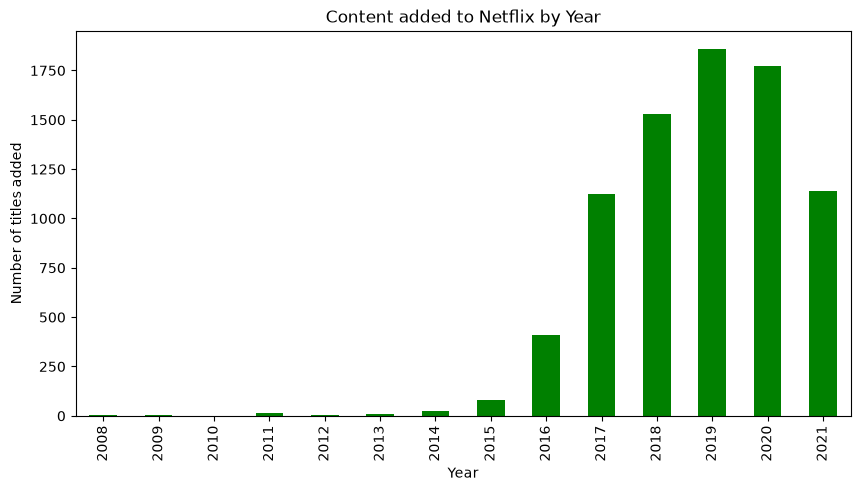

In [74]:
date_added.sort_index().plot(
    kind = 'bar',
    figsize = (10, 5),
    color = 'green'
)

plt.xlabel("Year")
plt.ylabel("Number of titles added")
plt.title("Content added to Netflix by Year")
plt.show()


Most of the movies added to netflix in 2019 and it is growing every year

In [75]:
# content added by month

df['date_added'].dt.month.value_counts().head(12)

date_added
12    758
7     708
1     701
10    701
4     694
3     685
11    671
8     667
9     661
6     633
5     545
2     540
Name: count, dtype: int64

Most of the movies and shows are added in December where least in February

In [76]:
# Average movies duration

durations = df[df['type'] == 'Movie']['duration'].str.replace(' min', '')
durations.isnull().sum()
durations = durations.dropna()

durations = durations.astype(int)
durations.mean()

np.float64(100.51802356251099)

we get average Movie watchtime about 100.5 minutes.

In [77]:
# longest movies durations

durations.max()

np.int64(312)

The longest movie duration is 312 minutes , that is 05:12 hours

In [78]:
# shows with most seasons

seasons = df[df['type'] == 'TV Show']['duration'].str.replace(' Seasons', '')
seasons = seasons.str.replace(' Season', '')
seasons = seasons.astype(int)

most_seasons_webseries = df[df['type'] == 'TV Show'][seasons == seasons.max()]['title']
most_seasons_webseries

548    Grey's Anatomy
Name: title, dtype: str

In [79]:
# Movies vs TV shows each year

types = ['Movie', 'TV Show']
Movies_vs_TV_Shows = df.groupby(['release_year', 'type']).size().unstack(fill_value = 0)
Movies_vs_TV_Shows

type,Movie,TV Show
release_year,,
1942,2,0
1943,3,0
1944,3,0
1945,3,1
1946,1,1
...,...,...
2017,730,236
2018,713,324
2019,565,348


In [80]:
# Top Genres by movies

df[df['type'] == 'Movie']['listed_in'].str.split(',').explode().str.strip().value_counts().head(10)


listed_in
International Movies        2543
Dramas                      2316
Comedies                    1580
Action & Adventure           817
Documentaries                794
Independent Movies           745
Romantic Movies              588
Thrillers                    549
Children & Family Movies     535
Horror Movies                340
Name: count, dtype: int64

Shows that most of the movies comes under International Movies genre.

In [81]:
# Top genres by TV shows

df[df['type'] == 'TV Show']['listed_in'].str.split(',').explode().str.strip().value_counts().head(10)


listed_in
International TV Shows    1126
TV Dramas                  662
TV Comedies                493
Crime TV Shows             420
Kids' TV                   368
Docuseries                 329
Romantic TV Shows          299
British TV Shows           236
Reality TV                 205
TV Action & Adventure      152
Name: count, dtype: int64

And the most genre in Tv shows is 'International TV Shows'

In [82]:
# Top Countries by movies

df[df['type'] == 'Movie']['country'].str.split(',').explode().str.strip().value_counts().head(10)

country
United States     2752
India              962
United Kingdom     534
Canada             319
France             303
Germany            182
Spain              171
Japan              119
China              114
Mexico             111
Name: count, dtype: int64

Most of the Movies are from United States on Netflix

In [83]:
# Top Countries by TV shows
df[df['type'] == 'TV Show']['country'].str.split(',').explode().str.strip().value_counts().head(10)

country
United States     932
United Kingdom    271
Japan             197
South Korea       170
Canada            126
France             90
India              84
Taiwan             70
Australia          64
Spain              61
Name: count, dtype: int64

Most of the Tv Shows are from united states on Netflix

In [84]:
# Business Questions

1. Which country has highest Netflix content ?

--> United States has highest Netflix Content with 2812 Movies and TV Shows.

2. Does Netflix has more Movies or TV Shows ? 

In [85]:
Movies_vs_TV_Shows.sum()

type
Movie      5690
TV Show    2274
dtype: int64

Answer : Netflix has More Movies (5690) than TV shows .

Insight : This indicates that Netflix focus on Movies more than TV Shows.

3. Which Director has directed the most netflix titles ? 

In [86]:
most_working_directors = Top_Directors.head(1)
most_working_directors

director
Raúl Campos, Jan Suter    18
Name: count, dtype: int64

Answer : Most directed person on Netflix titles is Raul Campos with 18 Movies/TV Shows.

Insight :  This reveals a core component of Netflix's early global expansion strategy. Instead of relying solely on expensive, slow-to-produce Hollywood movies, Netflix prioritized high-volume, low-cost, hyper-localized content to quickly grow and retain its subscriber base in international markets.

4. Which actors appears most frequently ?

In [87]:
most_frequent_actors.head(3)

cast
Anupam Kher         43
Shah Rukh Khan      34
Naseeruddin Shah    31
Name: count, dtype: int64

The most frequent actor on Netflix content is Anupam Kher.
And we can See that All 3 are Indian.

Insight : Indian actors dominate the top three most frequent actors, suggesting a strong representation of Indian content in the Netflix catalog.

5. Which genres are most common ?

In [88]:
genres.value_counts().head(4)

listed_in
International Movies      2543
Dramas                    2316
Comedies                  1580
International TV Shows    1126
Name: count, dtype: int64

Most Common genres Ranked :
 International Movies
 Dramas
 Comedies
 International TV shows

Insight : The Top 4 shows that people watch International Content which is not of their home country , majorly those are language learner's and are cultural and content explorers, that shows netflix has a very good movies/ shows knoledgeble audience.

6. Which content rating is most common ?

In [89]:
ratings

rating
TV-MA       2929
TV-14       1927
R            788
TV-PG        771
PG-13        482
PG           281
TV-Y7        235
TV-Y         227
TV-G         190
NR            79
G             41
TV-Y7-FV       5
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

Answer : TV-MA rating is most common.
         TV-MA rating stands for Mature Audience Only
         and indicates that indicates that a television program is designed specifically for adults and is unsuitable for children under the age of 17

Insight : That means , most of the Netflix audience are mature people.

7. Which year has highest number of releases ?

In [90]:
highest_release_year.head(1)

release_year
2018    1037
Name: count, dtype: int64

Answer : Year 2018 has highest number of releases of Movies/TV shows , about 1037.

Insight : 2018 marks the peak of Netflix’s shift from a licensing platform to a massive content producer.

In [91]:
# Conclusion

Key Findings

• Movies dominate Netflix.

• USA contributes the largest amount of content.

• TV-MA is the most common rating.

• International Movies are the most popular genre.

• 2018 saw the highest number of releases.

• Most content was added during 2019.

• Anupam Kher appears in the highest number of Netflix titles.